# 05 — Time-Based Analysis
Temporal patterns in foot traffic using frame index as a time proxy.

In [1]:
import sys
import datetime
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io
import seaborn as sns

sys.path.insert(0, '..')
from src.heatmap import FLOOR_W, FLOOR_H, CAM_W, CAM_H, FLOOR_POLYGON, make_floor_canvas, build_heatmap, backproject

sns.set_theme(style='whitegrid')

RAW       = Path('../data/raw')
PROCESSED = Path('../data/processed')

gt = scipy.io.loadmat(RAW / 'mall_gt.mat')
gt_counts = gt['count'].flatten()  # shape (2000,)

## Time metadata check

Before splitting into time windows we need to know whether the dataset carries
real timestamps. Three sources checked:

| Source | Result |
|---|---|
| `mall_gt.mat` keys | `frame`, `count` only — no time field |
| Frame JPEG EXIF | No EXIF data in any frame |
| File modification times | All identical — set at dataset extraction, not recording |

**Conclusion:** no usable time metadata exists. `frame_id` (1–2000) is used as a
monotonic time proxy throughout this notebook.

## Camera fps & video duration

Provide the camera capture rate. In a production frontend this would be a user input field.

In [2]:
# ── User input ───────────────────────────────────────────────────────────────
CAMERA_FPS = 1  # Hz — replace with actual camera spec

# ── Derived ───────────────────────────────────────────────────────────────────
N_FRAMES    = len(gt_counts)
duration_s  = N_FRAMES / CAMERA_FPS
duration_min = duration_s / 60

print(f'Camera rate:    {CAMERA_FPS} fps')
print(f'Total frames:   {N_FRAMES}')
print(f'Video duration: {duration_min:.1f} min ({duration_s:.0f}s)')

Camera rate:    1 fps
Total frames:   2000
Video duration: 33.3 min (2000s)


## Time window of interest

Specify the analysis window as clock times. Frame 1 is anchored at 11:00 AM.
In a production frontend this would be a time-range picker.

In [3]:
# ── Reference anchor ─────────────────────────────────────────────────────────
REFERENCE_TIME = datetime.time(11, 0)  # frame 1 = 11:00 AM

# ── User input ───────────────────────────────────────────────────────────────
WINDOW_START = datetime.time(11, 0) 
WINDOW_END   = datetime.time(11, 10) 

# ── Convert to frame indices ──────────────────────────────────────────────────
def time_to_frame(t, reference, fps):
    ref_dt = datetime.datetime.combine(datetime.date.today(), reference)
    t_dt   = datetime.datetime.combine(datetime.date.today(), t)
    delta_s = (t_dt - ref_dt).total_seconds()
    return max(1, min(N_FRAMES, round(delta_s * fps) + 1))

frame_start = time_to_frame(WINDOW_START, REFERENCE_TIME, CAMERA_FPS)
frame_end   = time_to_frame(WINDOW_END,   REFERENCE_TIME, CAMERA_FPS)

print(f'Reference:    frame 1 = {REFERENCE_TIME.strftime("%H:%M")}'
      f'  →  last frame = {(datetime.datetime.combine(datetime.date.today(), REFERENCE_TIME) + datetime.timedelta(seconds=duration_s)).strftime("%H:%M")}')
print(f'Window:       {WINDOW_START.strftime("%H:%M")} – {WINDOW_END.strftime("%H:%M")}')
print(f'Frame range:  {frame_start} – {frame_end}  ({frame_end - frame_start + 1} frames)')

Reference:    frame 1 = 11:00  →  last frame = 11:33
Window:       11:00 – 11:10
Frame range:  1 – 601  (601 frames)


## Original Homography (5-pt)

### Heatmap for selected time window

All frames:    35194 detections
Window frames: 9552 detections  (11:00–11:10, frames 1–601)


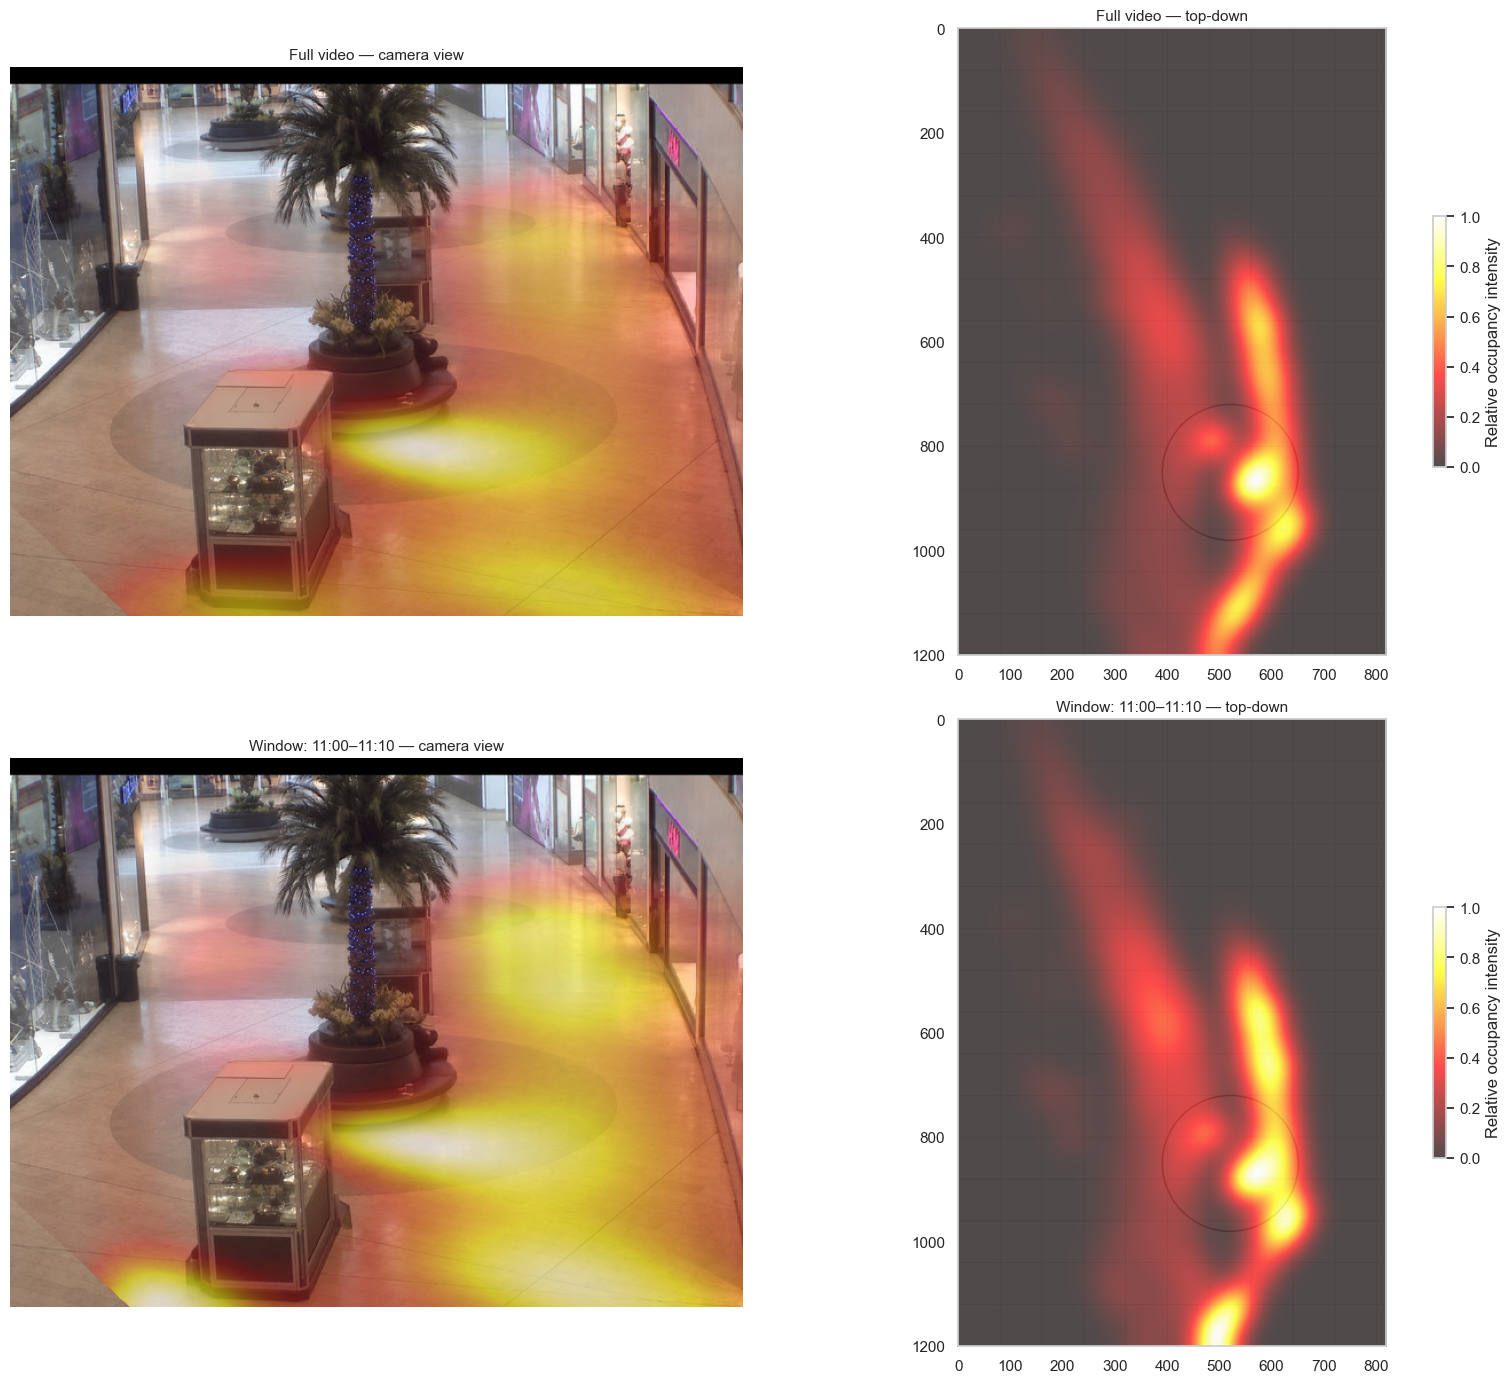

In [4]:
H     = np.load(PROCESSED / 'homography.npy')
H_inv = np.linalg.inv(H)

_frame85_raw = plt.imread('../reports/figures/Empty_frame_85.jpg')
_frame85_rgb = (_frame85_raw[:, :, :3] * 255).astype(np.uint8) if _frame85_raw.max() <= 1 else _frame85_raw[:, :, :3]
FRAME85 = cv2.resize(_frame85_rgb, (CAM_W, CAM_H))

projected = pd.read_csv(PROCESSED / 'projected_detections.csv')
window    = projected[projected['frame_id'].between(frame_start, frame_end)]

heatmap_all    = build_heatmap(projected, 'px', 'py', [FLOOR_W, FLOOR_H], [[0, FLOOR_W], [0, FLOOR_H]])
heatmap_window = build_heatmap(window, 'px', 'py', [FLOOR_W, FLOOR_H], [[0, FLOOR_W], [0, FLOOR_H]])

print(f'All frames:    {len(projected)} detections')
print(f'Window frames: {len(window)} detections  '
      f'({WINDOW_START.strftime("%H:%M")}–{WINDOW_END.strftime("%H:%M")}, '
      f'frames {frame_start}–{frame_end})')

labels   = ['Full video', f'Window: {WINDOW_START.strftime("%H:%M")}–{WINDOW_END.strftime("%H:%M")}']
heatmaps = [heatmap_all, heatmap_window]

fig, axes = plt.subplots(2, 2, figsize=(16, 14),
                         gridspec_kw={'width_ratios': [CAM_W, FLOOR_W]})

for row, (hm, label) in enumerate(zip(heatmaps, labels)):
    axes[row, 0].imshow(backproject(hm, H_inv, FRAME85))
    axes[row, 0].grid(False)
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f'{label} — camera view', fontsize=11)

    axes[row, 1].imshow(make_floor_canvas(), extent=[0, FLOOR_W, FLOOR_H, 0])
    im = axes[row, 1].imshow(hm, extent=[0, FLOOR_W, FLOOR_H, 0],
                              cmap='hot', alpha=0.7, vmin=0, vmax=1)
    plt.colorbar(im, ax=axes[row, 1], label='Relative occupancy intensity', shrink=0.4)
    axes[row, 1].grid(False)
    axes[row, 1].set_title(f'{label} — top-down', fontsize=11)

plt.tight_layout()
plt.show()

## New Homography (10-pt)

All frames:    36014 detections
Window frames: 9775 detections  (11:00–11:10, frames 1–601)


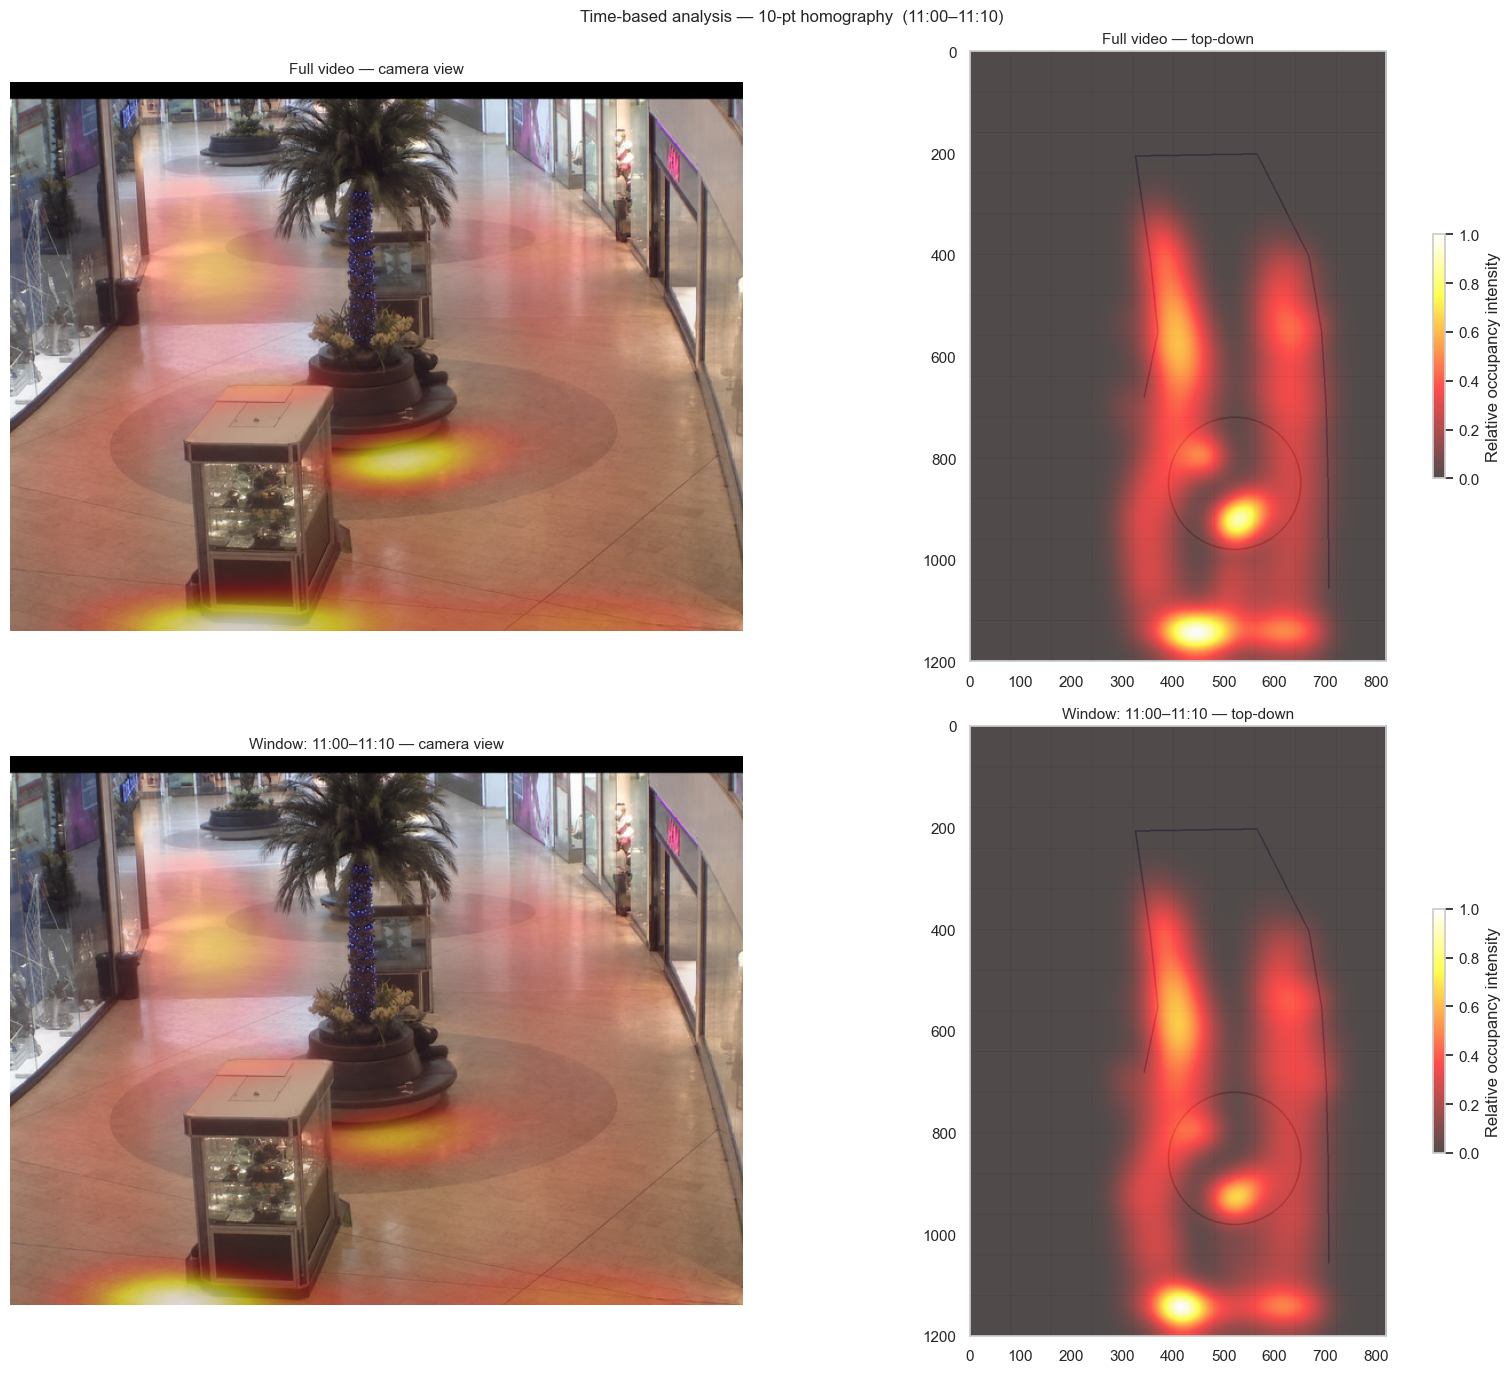

In [5]:
H_new     = np.load(PROCESSED / 'homography_10pt.npy')
H_new_inv = np.linalg.inv(H_new)

projected_10pt = pd.read_csv(PROCESSED / 'projected_detections_10pt.csv')
window_10pt    = projected_10pt[projected_10pt['frame_id'].between(frame_start, frame_end)]

heatmap_all_10pt    = build_heatmap(projected_10pt, 'px', 'py', [FLOOR_W, FLOOR_H], [[0, FLOOR_W], [0, FLOOR_H]])
heatmap_window_10pt = build_heatmap(window_10pt, 'px', 'py', [FLOOR_W, FLOOR_H], [[0, FLOOR_W], [0, FLOOR_H]])

print(f'All frames:    {len(projected_10pt)} detections')
print(f'Window frames: {len(window_10pt)} detections  '
      f'({WINDOW_START.strftime("%H:%M")}–{WINDOW_END.strftime("%H:%M")}, '
      f'frames {frame_start}–{frame_end})')

labels   = ['Full video', f'Window: {WINDOW_START.strftime("%H:%M")}–{WINDOW_END.strftime("%H:%M")}']
heatmaps = [heatmap_all_10pt, heatmap_window_10pt]

fig, axes = plt.subplots(2, 2, figsize=(16, 14),
                         gridspec_kw={'width_ratios': [CAM_W, FLOOR_W]})

for row, (hm, label) in enumerate(zip(heatmaps, labels)):
    axes[row, 0].imshow(backproject(hm, H_new_inv, FRAME85))
    axes[row, 0].grid(False)
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f'{label} — camera view', fontsize=11)

    axes[row, 1].imshow(make_floor_canvas(polygon_pts=FLOOR_POLYGON), extent=[0, FLOOR_W, FLOOR_H, 0])
    im = axes[row, 1].imshow(hm, extent=[0, FLOOR_W, FLOOR_H, 0],
                              cmap='hot', alpha=0.7, vmin=0, vmax=1)
    plt.colorbar(im, ax=axes[row, 1], label='Relative occupancy intensity', shrink=0.4)
    axes[row, 1].grid(False)
    axes[row, 1].set_title(f'{label} — top-down', fontsize=11)

plt.suptitle(f'Time-based analysis — 10-pt homography  '
             f'({WINDOW_START.strftime("%H:%M")}–{WINDOW_END.strftime("%H:%M")})', fontsize=12)
plt.tight_layout()
plt.show()